In [1]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir("/content/")


['.config',
 'train',
 'val',
 'yolov8n.pt',
 'test',
 'data.yaml',
 'dataset',
 'drive',
 'sample_data']

In [ ]:
import os
os.listdir("/content/")


['.config',
 'train',
 'val',
 'yolov8n.pt',
 'test',
 'data.yaml',
 'dataset',
 'drive',
 'sample_data']

In [ ]:
import os

print(os.listdir("/content/train"))
print(os.listdir("/content/val"))


['train.txt']
['val.txt']


In [ ]:
import zipfile
import os

zip_file_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/road.zip"
extraction_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/"

# Ensure the target extraction directory exists
os.makedirs(extraction_path, exist_ok=True)

# Extract the files if they haven't been extracted already (idempotent)
# Check if the zip file exists and if a representative subdirectory (e.g., 'val') inside the extraction path doesn't exist
if os.path.exists(zip_file_path) and not os.path.exists(os.path.join(extraction_path, "val")):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"Extracted {zip_file_path} to {extraction_path}")
else:
    print(f"Skipped extraction: {zip_file_path} does not exist or files are already extracted to {extraction_path}.")

Extracted /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/road.zip to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/


In [ ]:
import os

# List contents of the target extraction path in Google Drive
drive_extraction_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/"

if os.path.exists(drive_extraction_path):
    print(f"Contents of {drive_extraction_path}:")
    for item in os.listdir(drive_extraction_path):
        print(f"- {item}")
else:
    print(f"The directory {drive_extraction_path} does not exist. Please ensure your Google Drive is mounted correctly and the path is accurate.")


Contents of /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/:
- L3NoobDEVLorion.ipynb
- data.yaml
- test
- train
- val
- .ipynb_checkpoints


In [ ]:
import os

os.listdir("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/train/images")[:5]

['00033_jpg.rf.261cd5fb19baf8fd8da0c39ce2171ff2.jpg',
 '00033_jpg.rf.d0b705c843555cbd4a92e322de8ecb82.jpg',
 '00034_jpg.rf.2e4b74d092bf8a1dbcf398d9a9a36f03.jpg',
 '00034_jpg.rf.a8540e9f6200176bc4bb5ba26443cc23.jpg',
 '00035_jpg.rf.141e9d256c073c9244e4b141ee70bac3.jpg']

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# Seeing data.yml errors
data_yaml_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml"
try:
    with open(data_yaml_path, 'r') as f:
        yaml_content = f.read()
    print(f"Content of {data_yaml_path}:\n---\n{yaml_content}\n---")
    if not yaml_content.strip():
        print("Warning: The data.yaml file appears to be empty or contains only whitespace.")
except FileNotFoundError:
    print(f"Error: The file {data_yaml_path} was not found.")
except Exception as e:
    print(f"An error occurred while reading {data_yaml_path}: {e}")


Content of /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml:
---
%%writefile /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml
path: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW

train: train/images
val: val/images
test: test/images

nc: 3
names: ['Pothole', 'Speedbump', 'Crack']

---


### 1. Run More Epochs for Better Convergence

Let's resume training the model from your current best checkpoint (`best.pt`) and train for a total of 100 epochs, with patience set to 20. This will allow the model to converge more naturally and potentially improve overall performance, especially mAP.

In [3]:
from ultralytics import YOLO

# Load the best trained model weights to resume training
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Resume training for more epochs
model.train(
    data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
    epochs=100,       # total, so effectively 50 more epochs
    patience=0,       # Set patience to 0 to disable early stopping and run for full epochs
    batch=16,         # Keeping initial batch size suitable for T4
    imgsz=512,        # Keeping initial image size suitable for T4
    lr0=0.0005,       # start lower since weights are already trained
    lrf=0.01,
    resume=False,     # False when loading from best.pt for fine-tuning
    project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",
    name="road_anomaly_v3", # New experiment name for this 100-epoch run
    verbose=True,
    cache="disk",
    augment=True,
    save=True,
    warmup_epochs=2,
    weight_decay=0.0005,
    hsv_v=0.4,           # brightness variation for road lighting
    flipud=0.0,          # never flip roads vertically
    fliplr=0.5,
    mosaic=1.0,
    device=0,
)

print("\nTraining resumed. Check the output logs and the 'road_anomaly_v3' directory for progress.")

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt, momentum=0.937, mosaic=1.0,

### Testing and Visualization for `road_anomaly_v3`

Now that the `road_anomaly_v3` model has completed training for 100 epochs, let's perform a full evaluation on the test set and visualize its performance metrics, including per-class evaluation, confusion matrix, and precision-recall curves. We will use the `best.pt` weights from this latest run.

In [5]:
from ultralytics import YOLO

# Load the best trained model weights from road_anomaly_v3
model_v3 = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt")

# Run full evaluation on the test set for road_anomaly_v3
# This will generate the metrics object and save plots to the specified project/name directory
metrics_v3 = model_v3.val(
    data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
    split="test", # Ensure evaluation is on the test split
    imgsz=512, # Use the same image size as during training
    batch=16,
    project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",
    name="road_anomaly_v3_full_evaluation", # unique name for this evaluation
    save_json=True,
    save_txt=True,
    plots=True
)

print("\n--- Full Evaluation Results on Test Set (road_anomaly_v3) ---")
print(f"Overall Precision (P): {metrics_v3.box.p.mean():.3f}")
print(f"Overall Recall (R): {metrics_v3.box.r.mean():.3f}")
print(f"Overall mAP@0.5: {metrics_v3.box.map50:.3f}")
print(f"Overall mAP@0.5:0.95: {metrics_v3.box.map:.3f}")

print("\nPer-Class Evaluation Results (road_anomaly_v3):")
class_names_v3 = [name for name in model_v3.names.values()]
for i, name in enumerate(class_names_v3):
    if i < len(metrics_v3.box.p):
        # Corrected: Use metrics_v3.box.maps[i] for per-class mAP@0.5
        print(f"{name:12s}  P={metrics_v3.box.p[i]:.3f}  R={metrics_v3.box.r[i]:.3f}  AP50={metrics_v3.box.maps[i]:.3f}")


Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.6 ms, read: 36.6±21.1 MB/s, size: 92.4 KB)
val: Scanning /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/labels.cache... 928 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 928/928 229.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 1.5it/s 39.3s
                   all        928       1455      0.886      0.827      0.882      0.602
               Pothole        291        611      0.856      0.753      0.822      0.484
             Speedbump        360        415      0.939      0.923      0.946      0.678
                 Crack        276        429      0.862      0.804      0.877      0.643
Speed: 1.0ms preprocess, 3.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Saving /cont

### Confusion Matrix and Precision-Recall Curve (road_anomaly_v3)

These plots are automatically generated and saved during the `model.val()` command. Let's display them using the `metrics_v3` object generated above.

Using existing 'metrics_v3' object for plotting.

Displaying Confusion Matrix...


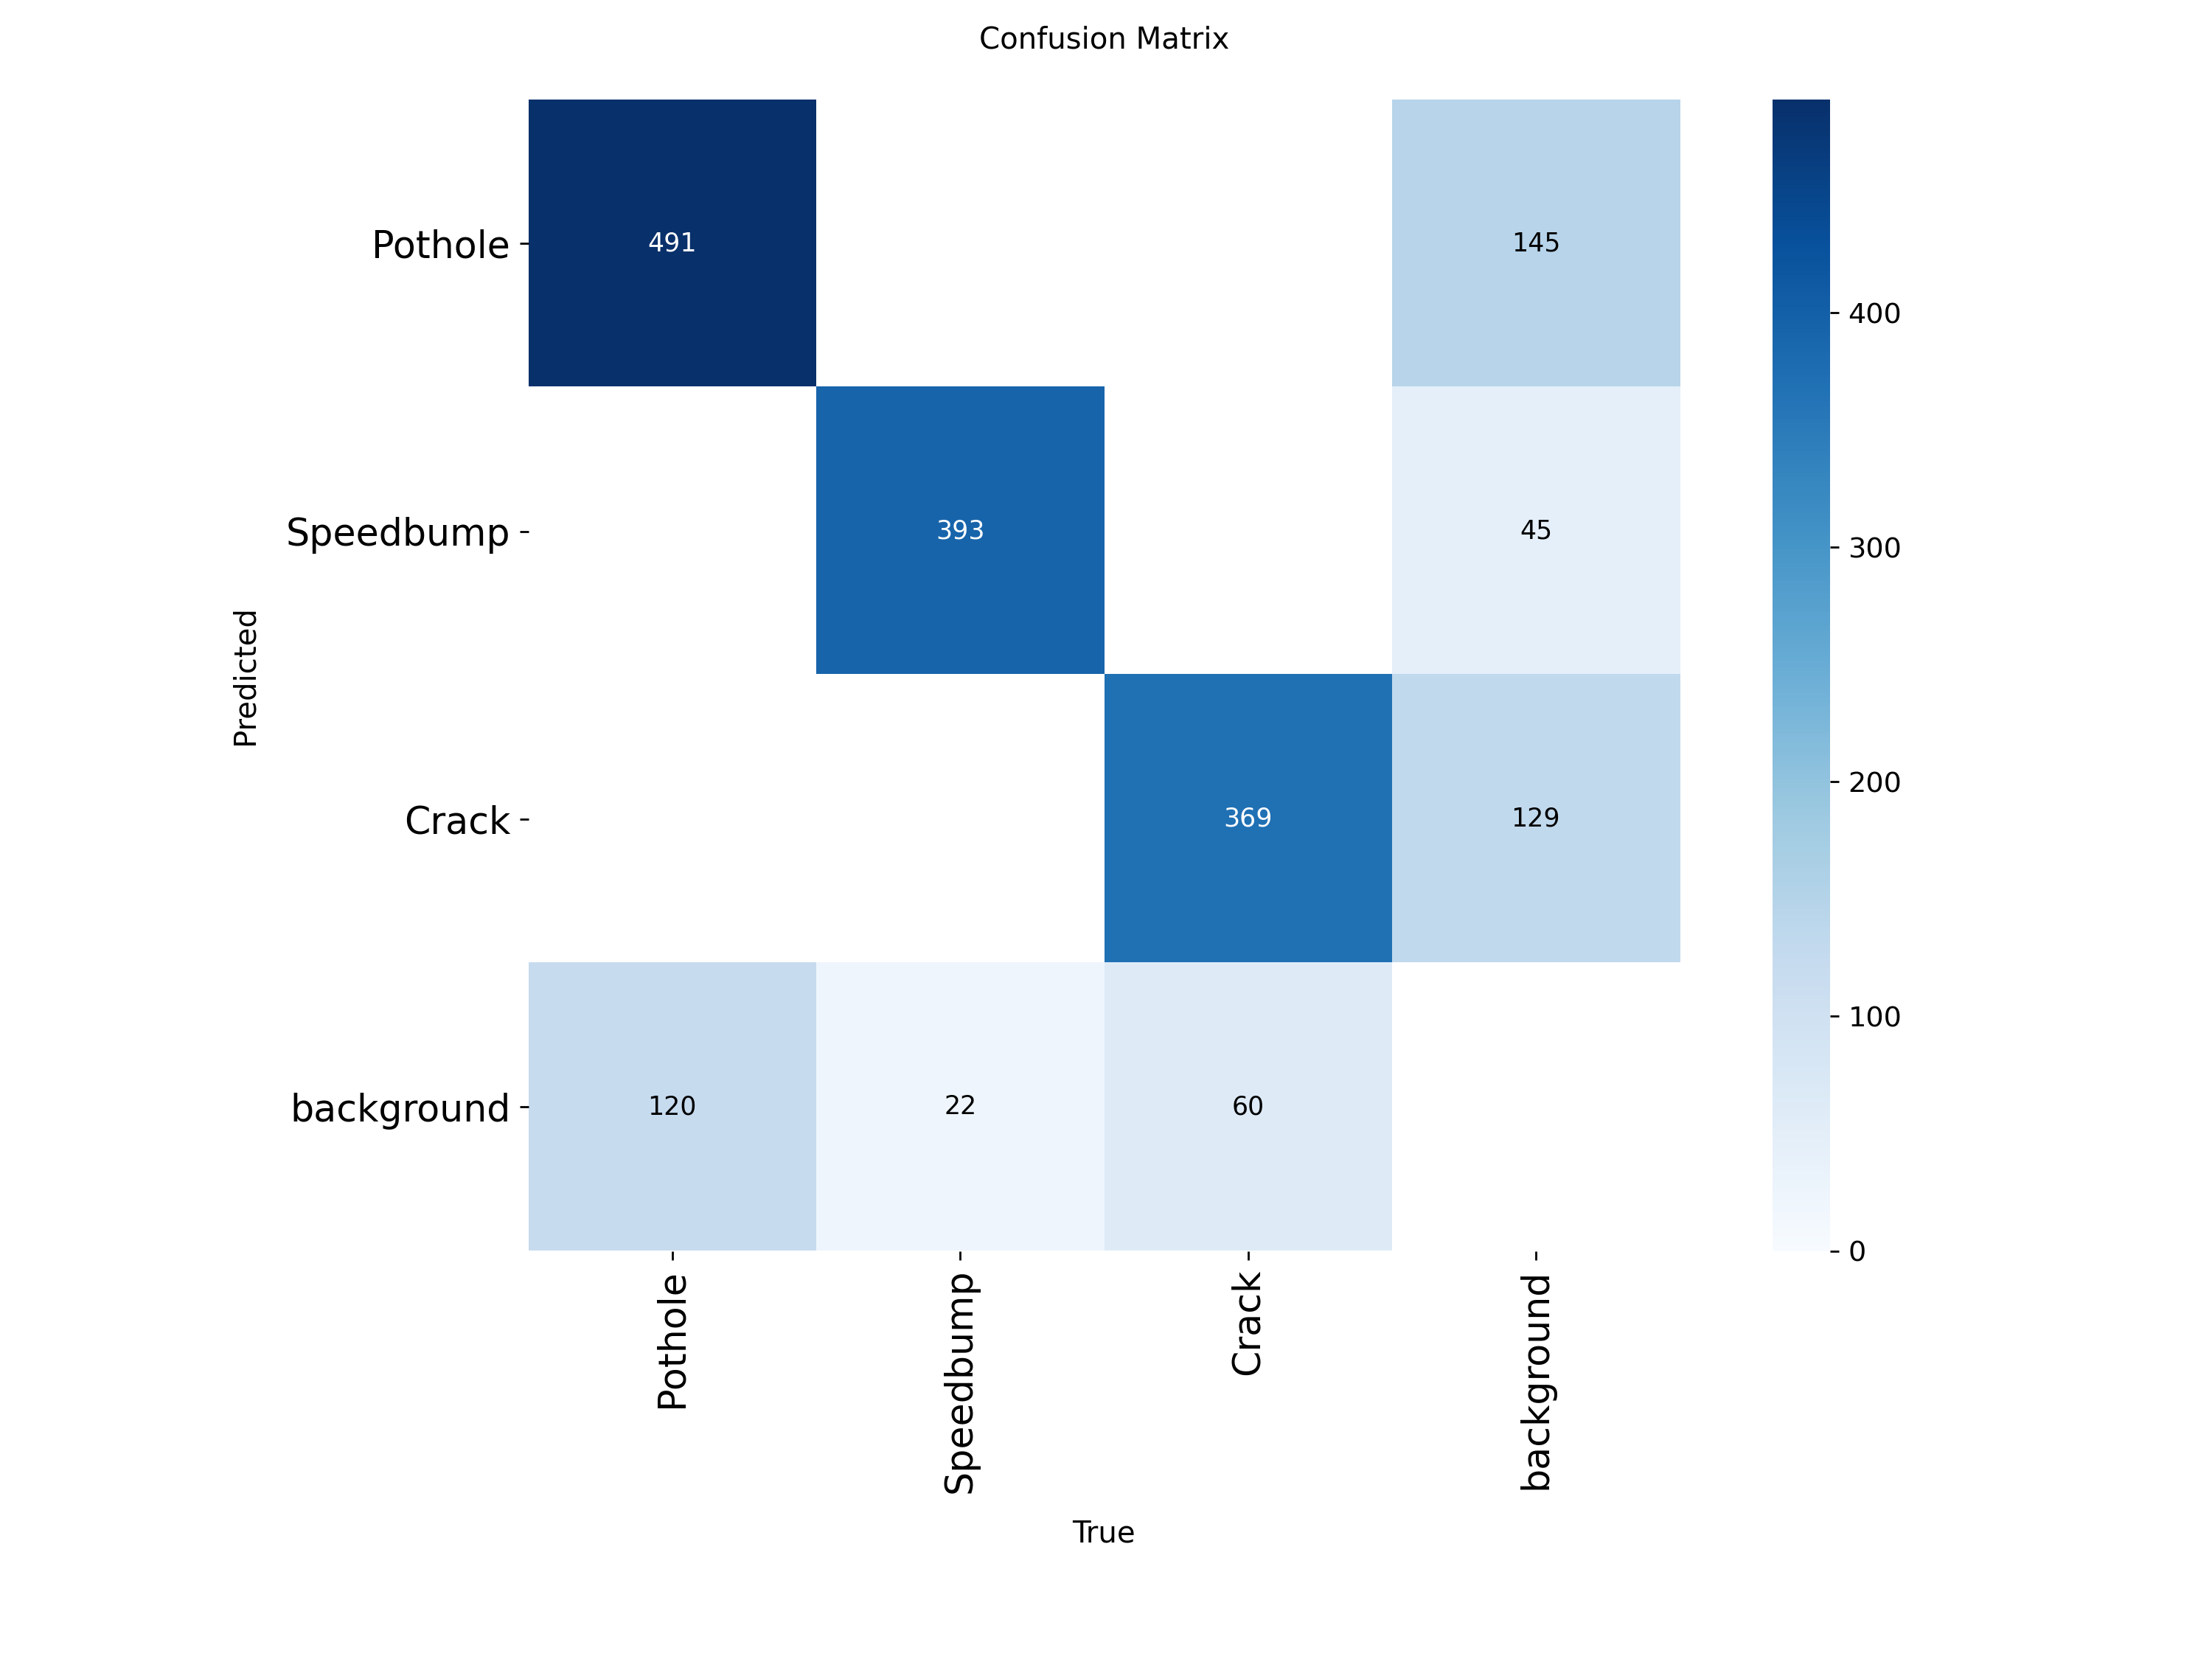

Confusion Matrix displayed from: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3_full_evaluation2/confusion_matrix.png

Displaying Precision-Recall Curve...
Error: PR_curve.png not found at /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3_full_evaluation2/PR_curve.png.


In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

# Ensure metrics_v3 object is available from the previous cell
try:
    if 'metrics_v3' not in locals() or metrics_v3 is None:
        raise NameError("'metrics_v3' object not found")
    print("Using existing 'metrics_v3' object for plotting.")
except NameError:
    print("Error: 'metrics_v3' object not available. Please ensure the full evaluation cell was run successfully.")

if 'metrics_v3' in locals() and metrics_v3 is not None:
    print("\nDisplaying Confusion Matrix...")
    confusion_matrix_path_v3 = os.path.join(metrics_v3.save_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_matrix_path_v3):
        display(Image(filename=confusion_matrix_path_v3))
        print(f"Confusion Matrix displayed from: {confusion_matrix_path_v3}")
    else:
        print(f"Error: confusion_matrix.png not found at {confusion_matrix_path_v3}.")

    print("\nDisplaying Precision-Recall Curve...")
    pr_curve_path_v3 = os.path.join(metrics_v3.save_dir, 'PR_curve.png')
    if os.path.exists(pr_curve_path_v3):
        display(Image(filename=pr_curve_path_v3))
        print(f"Precision-Recall Curve displayed from: {pr_curve_path_v3}")
    else:
        print(f"Error: PR_curve.png not found at {pr_curve_path_v3}.")


### Anomaly Counts in Test Images (road_anomaly_v3)

Let's count how many of each type of anomaly are detected across the entire test dataset using our `road_anomaly_v3` model.

In [7]:
from ultralytics import YOLO
from collections import Counter
import os

# Load the best trained model weights from road_anomaly_v3
model_v3 = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt")

# Define the path to your test images directory
test_images_dir = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images"

# Initialize a Counter to store class counts
class_counts_v3 = Counter()

print(f"Running predictions on all images in: {test_images_dir}\n")

# Setting verbose=False to avoid excessive console output for each image
results_v3 = model_v3.predict(test_images_dir, imgsz=512, conf=0.3, verbose=False)

# Iterate through the results and count detected classes
for r in results_v3:
    for box in r.boxes:
        class_id = int(box.cls[0]) # Get the class ID for each detected box
        class_counts_v3[class_id] += 1


# The model.names attribute provides the mapping from integer ID to class string
class_names_map_v3 = model_v3.names # This will be a dictionary like {0: 'Pothole', 1: 'Speedbump', ...}

print("\nDetected Class Counts in Test Images (road_anomaly_v3)")
if class_counts_v3:
    for class_id, count in class_counts_v3.items():
        class_name = class_names_map_v3.get(class_id, f"Unknown Class (ID: {class_id})")
        print(f"- {class_name}: {count} detections")
else:
    print("No anomalies detected across the test images with the given confidence threshold.")


Running predictions on all images in: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images


Detected Class Counts in Test Images (road_anomaly_v3)
- Crack: 462 detections
- Pothole: 595 detections
- Speedbump: 436 detections


### Visualizing Predictions on Sample Images (road_anomaly_v3)

Let's visually inspect how the `road_anomaly_v3` model performs on a few sample test images.


--- Visualizing Predictions for: 00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg (road_anomaly_v3) ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg: 512x512 2 Cracks, 6.9ms
Speed: 1.7ms preprocess, 6.9ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions_v3/00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a


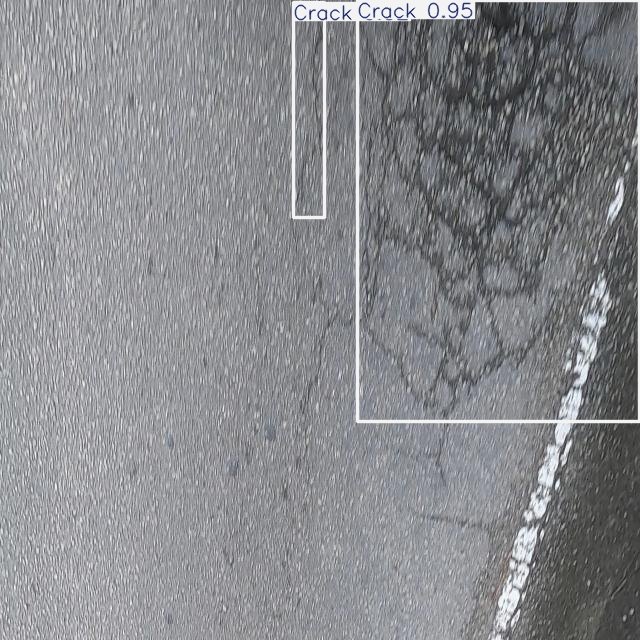

Detected anomalies:
  Crack (Confidence: 0.95)
  Crack (Confidence: 0.32)

--- Visualizing Predictions for: 00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd.jpg (road_anomaly_v3) ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd.jpg: 512x512 1 Crack, 10.7ms
Speed: 4.9ms preprocess, 10.7ms inference, 2.1ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions_v3/00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd


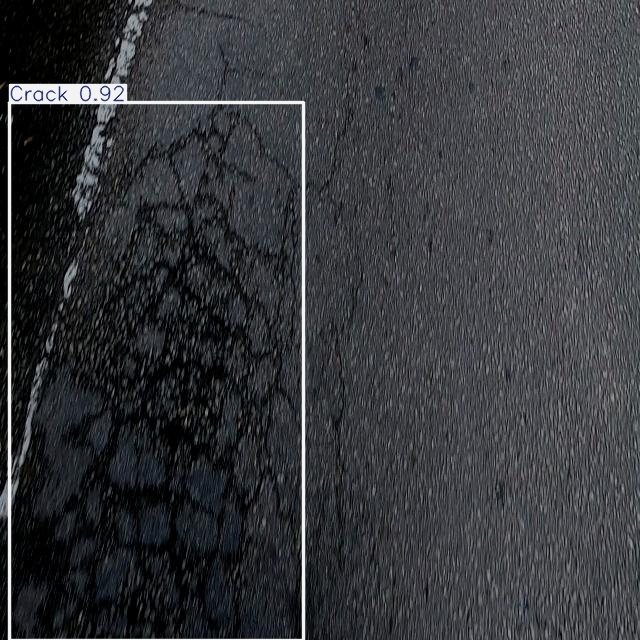

Detected anomalies:
  Crack (Confidence: 0.92)

--- Visualizing Predictions for: 00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd8.jpg (road_anomaly_v3) ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd8.jpg: 512x512 1 Crack, 8.8ms
Speed: 2.8ms preprocess, 8.8ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions_v3/00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd8


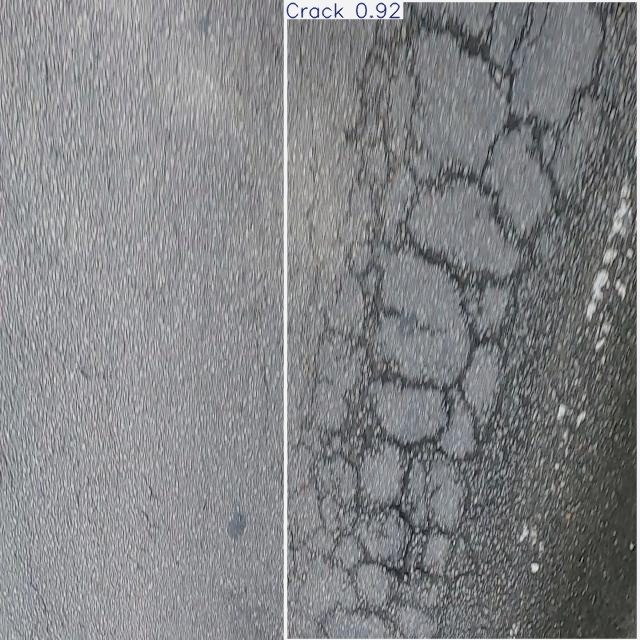

Detected anomalies:
  Crack (Confidence: 0.92)

--- Visualizing Predictions for: 00100_jpg.rf.c4809007643425568a57af8267f8d03e.jpg (road_anomaly_v3) ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00100_jpg.rf.c4809007643425568a57af8267f8d03e.jpg: 512x512 1 Crack, 9.5ms
Speed: 2.8ms preprocess, 9.5ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions_v3/00100_jpg.rf.c4809007643425568a57af8267f8d03e


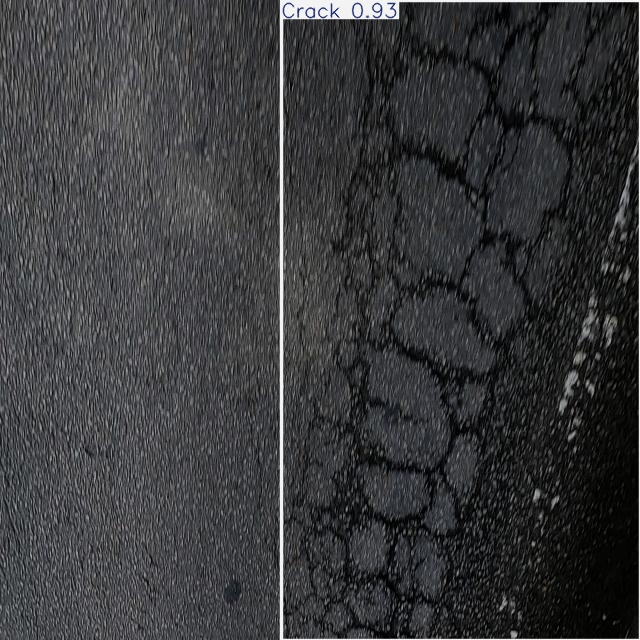

Detected anomalies:
  Crack (Confidence: 0.93)

--- Visualizing Predictions for: Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg (road_anomaly_v3) ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg: 512x512 1 Speedbump, 15.4ms
Speed: 2.8ms preprocess, 15.4ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions_v3/Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784


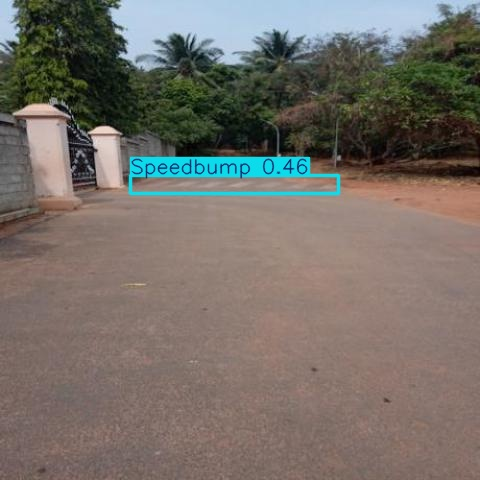

Detected anomalies:
  Speedbump (Confidence: 0.46)


In [8]:
from ultralytics import YOLO
import os
from IPython.display import Image, display

# Load the best trained model weights from road_anomaly_v3
model_v3 = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt")

# Define the directory containing test images
test_images_dir = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images"

# Sample images to display (can be adjusted)
sample_images_to_display = [
    '00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg',
    '00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd.jpg',
    '00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd8.jpg',
    '00100_jpg.rf.c4809007643425568a57af8267f8d03e.jpg',
    'Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg'
]

# Define a temporary directory to save prediction results for displaying
save_prediction_display_dir_v3 = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions_v3"
os.makedirs(save_prediction_display_dir_v3, exist_ok=True)

for image_name in sample_images_to_display:
    image_path = os.path.join(test_images_dir, image_name)
    if os.path.exists(image_path):
        print(f"\n--- Visualizing Predictions for: {image_name} (road_anomaly_v3) ---")

        # Perform prediction and save the results in a unique subdirectory per image
        predict_results_v3 = model_v3.predict(
            image_path,
            imgsz=512,
            conf=0.3,
            save=True,
            save_conf=True,
            project=save_prediction_display_dir_v3,
            name=os.path.splitext(image_name)[0] # Use image name as run name for distinct subfolders
        )

        # Get the actual save directory from the results object and display the image
        if predict_results_v3 and hasattr(predict_results_v3[0], 'save_dir'):
            predicted_image_path_v3 = os.path.join(predict_results_v3[0].save_dir, image_name)
            if os.path.exists(predicted_image_path_v3):
                display(Image(filename=predicted_image_path_v3))
            else:
                print(f"Predicted image not found at {predicted_image_path_v3}")
        else:
             print(f"Could not determine save directory for {image_name}.")

        # Print detected anomalies
        if predict_results_v3 and len(predict_results_v3[0].boxes) > 0:
            print("Detected anomalies:")
            for box in predict_results_v3[0].boxes:
                class_id = int(box.cls)
                confidence = box.conf.item()
                class_name = model_v3.names[class_id]
                print(f"  {class_name} (Confidence: {confidence:.2f})")
        else:
            print("No anomalies detected.")
    else:
        print(f"Image not found: {image_path}")


### Exporting `road_anomaly_v3` Model for Mobile Applications

Now, let's export the newly trained `road_anomaly_v3` model (`best.pt`) to various formats optimized for mobile and edge devices. This step is crucial for deploying your anomaly detection model in applications for Android (using TFLite) and iOS (using ONNX or CoreML). All exported models will be saved in the `weights` directory of the `road_anomaly_v3` run.

In [9]:
from ultralytics import YOLO

# Load the best trained PyTorch model from road_anomaly_v3
model_v3 = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt")

print("Exporting model to ONNX (float32) for general mobile/edge deployment...")
# For general ONNX Runtime usage (Float32)
# `opset` ensures compatibility. `dynamic=False` is often preferred for deployment for fixed input size.
exported_onnx_path_v3 = model_v3.export(
    format="onnx",
    imgsz=512,
    opset=13, # A commonly supported opset for ONNX Runtime
    dynamic=False,
    simplify=True # Apply ONNX graph optimizations
)

print(f"ONNX (float32) export complete. Model saved to: {exported_onnx_path_v3}")


Exporting model to ONNX (float32) for general mobile/edge deployment...
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 210ms
Prepared 4 packages in 4.36s
Installed 4 packages in 306ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 5.8s
WARNING ⚠️ req

In [10]:
from ultralytics import YOLO

# Load the best trained PyTorch model from road_anomaly_v3
model_v3 = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt")

print("Exporting model to optimized ONNX (float16) for iOS / ONNX Runtime Mobile...")
# For iOS / ONNX Runtime Mobile (better for performance on supported mobile GPUs)
# `half=True` converts weights to float16, reducing size and improving performance on GPUs with float16 support.
exported_onnx_half_path_v3 = model_v3.export(
    format="onnx",
    simplify=True,
    half=True,
    imgsz=512,
    opset=17 # Newer opset for better mobile operator support if available
)

print(f"ONNX (float16) export complete. Model saved to: {exported_onnx_half_path_v3}")


Exporting model to optimized ONNX (float16) for iOS / ONNX Runtime Mobile...
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: converting to FP16...
ONNX: export success ✅ 1.3s, saved as '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.onnx' (5.9 MB)

Export complete (1.5s)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/roa

In [11]:
from ultralytics import YOLO

# Load the best trained PyTorch model from road_anomaly_v3
model_v3 = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt")

print("Exporting model to TFLite (int8 quantized) for Android...")
# For Android (TFLite \u2014 smallest & fastest on-device, suitable for mobile CPUs/NPUs)
# `int8=True` enables 8-bit integer quantization for maximum size reduction and speed.
# Note: INT8 quantization can sometimes reduce accuracy. Validation is recommended.
exported_tflite_path_v3 = model_v3.export(format="tflite", int8=True, imgsz=512)

print(f"TFLite (int8) export complete. Model saved to: {exported_tflite_path_v3}")


Exporting model to TFLite (int8 quantized) for Android...
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 2.01s
Prepared 5 packages in 228ms
Installed 5 packages in 9ms
 + ai-edge-litert==2.1.3
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.8
 + sng4onnx==2.0.1

requirements: AutoUpdate success ✅

In [14]:
from ultralytics import YOLO

# Load the best trained PyTorch model from road_anomaly_v3
model_v3 = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt")

print("Exporting model to CoreML for native iOS integration (without built-in NMS)...")
# Optional: CoreML for native iOS integration
# Set `nms=False` as a workaround for the 'output_shape' error.
# NMS can be implemented in the client application.
exported_coreml_path_v3 = model_v3.export(format="coreml", nms=False, imgsz=512)

print(f"CoreML export complete. Model saved to: {exported_coreml_path_v3}")

Exporting model to CoreML for native iOS integration (without built-in NMS)...
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)

CoreML: starting export with coremltools 9.0...


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 116.77 passes/s]


CoreML: export success ✅ 4.5s, saved as '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.mlpackage' (5.9 MB)

Export complete (4.8s)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.mlpackage imgsz=512 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.mlpackage imgsz=512 data=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml  
Visualize:       https://netron.app
CoreML export complete. Model saved to: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v3/weights/best.mlpackage


### 2. Fix the Recall Gap - Per-Class Evaluation

To identify if a specific class, likely 'Crack', has poor recall, we'll perform a detailed per-class evaluation. This will print the Precision (P), Recall (R), and mAP@0.5 (AP50) for each anomaly type. If 'Crack' recall is low (e.g., below 0.65), you might consider data augmentation techniques like `copy_paste` or gathering more training images for that class.

In [ ]:
from ultralytics import YOLO

# Load the best trained model for evaluation
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Run validation to get per-class metrics
metrics = model.val(
    data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
    imgsz=512,
    batch=16, # Use the same batch size as during training
    split='test', # Explicitly specify to run validation on the test split
    project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",
    name="road_anomaly_v1_per_class_evaluation", # A new name for evaluation results
    save_json=False, # No need to save json for this specific output
    save_txt=False, # No need to save txt for this specific output
    plots=False # No need to save plots for this specific output
)

print("\nPer-Class Evaluation Results:")
# Iterate and print per-class metrics
class_names = [name for name in model.names.values()]
for i, name in enumerate(class_names):
    # Ensure we don't go out of bounds if model.names has more/less entries than metrics.box.p
    if i < len(metrics.box.p):
        print(f"{name:12s}  P={metrics.box.p[i]:.3f}  R={metrics.box.r[i]:.3f}  AP50={metrics.box.map50_class[i]:.3f}")

print("\nOverall mAP@0.5: {metrics.box.map50:.3f}")

### 3. Validate Your TFLite Model Before Deploying

Before deploying the `int8` quantized TFLite model, it's crucial to verify its performance to ensure that quantization hasn't introduced unacceptable accuracy loss. This step involves loading the TFLite interpreter and inspecting its input/output tensors. You'll then need to run a representative set of test images through it and compare its detection results against the original PyTorch or ONNX model to assess any mAP drop.

*Note: Running inference for 20-30 images will be a follow-up step if needed, for now, we'll just set up the interpreter and check its details.*

In [ ]:
import numpy as np
import tensorflow as tf
import os

# Define the path to your int8 TFLite model
tflite_model_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best_int8.tflite"

if not os.path.exists(tflite_model_path):
    print(f"Error: TFLite model not found at {tflite_model_path}. Please ensure it was exported successfully.")
else:
    print(f"Loading TFLite model from: {tflite_model_path}")
    # Load the TFLite model and allocate tensors.
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    # Get input and output tensors details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    print("\n--- TFLite Model Details ---")
    print(f"Input shape: {input_details[0]['shape']}")
    print(f"Output shape: {output_details[0]['shape']}")
    print(f"Input dtype: {input_details[0]['dtype']}")
    print(f"Output dtype: {output_details[0]['dtype']}")

    print("\nTFLite interpreter loaded successfully. You can now proceed to run inference with test images.")



In [ ]:


from ultralytics import YOLO

# Load YOLOv8n pretrained model
model = YOLO("yolov8n.pt")  # small and fast for Colab T4

# Train the model on your road anomaly dataset
model.train(
    data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
    epochs=50,             # enough epochs for convergence
    batch=16,              # safe for Tesla T4 GPU
    imgsz=512,             # higher resolution for small anomalies
    cache='disk',          # deterministic caching
    augment=True,          # enable data augmentations
    save=True,             # save best weights automatically
    project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",  # folder to save results
    name="road_anomaly_v1",          # experiment name
    verbose=True
)

# After training, best weights are saved in:
# /content/runs/detect/road_anomaly_v1/weights/best.pt


Ultralytics 8.4.29 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_anomaly_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7856d951c4d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

confusion matrix

In [ ]:
import numpy as np

try:
    if 'metrics' not in locals() or metrics is None:
        raise NameError("'metrics' object not found")

    print(" Raw Confusion Matrix Data ")
    # Get the raw confusion matrix from the metrics object
    # The Ultralytics confusion matrix object has a .matrix attribute which is a numpy array
    raw_cm = metrics.confusion_matrix.matrix

    if raw_cm is not None:
        print("Shape of Confusion Matrix:", raw_cm.shape)
        print("Sum of Confusion Matrix elements:", np.sum(raw_cm))
        print("Non-zero elements in Confusion Matrix:", np.count_nonzero(raw_cm))
        print("Raw Confusion Matrix (first 5x5 if larger):\n", raw_cm[:5, :5])

        # Check if the matrix is mostly zeros or has very small values
        if np.sum(raw_cm) == 0:
            print("Warning: The raw confusion matrix is entirely zeros. This indicates no detections or ground truths were processed, or an issue during validation.")
        elif np.count_nonzero(raw_cm) < raw_cm.size / 2: # Arbitrary threshold, can be adjusted
            print("Note: The raw confusion matrix is sparse (many zeros).")

    else:
        print("Error: metrics.confusion_matrix.matrix is None.")

    # Also try to print normalized values if the raw matrix is available
    if raw_cm is not None and np.sum(raw_cm) > 0:
        print("\n Normalized Confusion Matrix Data (first 5x5 if larger)")
        # Ultralytics confusion matrix object also has a .plot() method that can return the normalized matrix
        # However, to avoid plotting, we can manually normalize for inspection if needed
        normalized_cm = raw_cm / raw_cm.sum(axis=1, keepdims=True)
        normalized_cm = np.nan_to_num(normalized_cm) # Replace NaNs with 0 (for rows with no true labels)
        print("Normalized Confusion Matrix (first 5x5 if larger):\n", normalized_cm[:5, :5])

except NameError:
    print("Error: 'metrics' object not available. Please ensure model.val() was run successfully.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Raw Confusion Matrix Data ---
Shape of Confusion Matrix: (4, 4)
Sum of Confusion Matrix elements: 1854.0
Non-zero elements in Confusion Matrix: 9
Raw Confusion Matrix (first 5x5 if larger):
 [[        478           0           0         150]
 [          0         389           0          84]
 [          0           0         358         165]
 [        133          26          71           0]]

--- Normalized Confusion Matrix Data (first 5x5 if larger) ---
Normalized Confusion Matrix (first 5x5 if larger):
 [[    0.76115           0           0     0.23885]
 [          0     0.82241           0     0.17759]
 [          0           0     0.68451     0.31549]
 [    0.57826     0.11304      0.3087           0]]


### 4. Precision-Recall Curve

This curve helps evaluate the trade-off between precision and recall for each class. Similar to the confusion matrix, this plot is automatically generated and saved during the `model.val()` command. We can display it here if the `metrics` object is available.


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

# Ensure the 'metrics' object is available.
# If your session restarted and you skipped the previous cell, you might need to re-run model.val() again.

try:
    if 'metrics' not in locals() or metrics is None:
        raise NameError("'metrics' object not found, skipping plot")
    print("Using existing 'metrics' object.")
except NameError:
    print("Error: 'metrics' object not available. Please ensure model.val() was run successfully.")
    print("You may need to re-run the previous model.val() cell (e.g., 701268db or new-cell-2) to generate the metrics object.")

if 'metrics' in locals() and metrics is not None:
    print("\nDisplaying Precision-Recall Curve...")

    # The PR curve is automatically saved to the metrics.save_dir by model.val(plots=True)
    pr_curve_path = os.path.join(metrics.save_dir, 'PR_curve.png')

    if os.path.exists(pr_curve_path):
        display(Image(filename=pr_curve_path))
        print(f"Precision-Recall Curve displayed from: {pr_curve_path}")
    else:
        print(f"Error: PR_curve.png not found at {pr_curve_path}. Please ensure model.val() was run with plots=True.")

    # The previous `plt.show()` was for an error-prone plot call, removing it.
    # plt.title('Precision-Recall Curve') # Title is usually part of the saved image
    # plt.show() # No need to call plt.show() after display(Image)

Using existing 'metrics' object.

Displaying Precision-Recall Curve...
Error: PR_curve.png not found at /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1_full_evaluation/PR_curve.png. Please ensure model.val() was run with plots=True.


In [ ]:
import os

# List contents of the directory where test_road.jpg was expected
inspection_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/"

if os.path.exists(inspection_path):
    print(f"Contents of {inspection_path}:")
    for item in os.listdir(inspection_path):
        print(f"- {item}")
else:
    print(f"The directory {inspection_path} does not exist.")

Contents of /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/:
- L3NoobDEVLorion.ipynb
- data.yaml
- test
- train
- val
- .ipynb_checkpoints
- runs


In [ ]:
from ultralytics import YOLO

# Load the best trained model weights
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Validate the model on the test dataset
# This will calculate metrics and generate plots like confusion matrix, PR curves, etc.
metrics = model.val(
    data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
    imgsz=512, # Use the same image size as during training
    batch=16, # Use the same batch size as during training
    split='test', # Explicitly specify to run validation on the test split
    project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",
    name="road_anomaly_v1_evaluation", # A new name for evaluation results
    save_json=True, # Save metrics to a json file
    save_txt=True, # Save detection results in txt format
    plots=True # Save plots like confusion matrix, PR curves
)

# Print key metrics
print("\n Model Evaluation Results ")
print(f"Precision (P): {metrics.box.p}") # Corrected access
print(f"Recall (R): {metrics.box.r}") # Corrected access
print(f"mAP@0.5: {metrics.box.map50}")
print(f"mAP@0.5:0.95: {metrics.box.map}")

# The generated plots (confusion matrix) will be saved in the run directory

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 0.3±0.2 MB/s, size: 85.2 KB)
val: Scanning /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/labels.cache... 928 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 928/928 53.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 4.8s/it 4:39
                   all        928       1455      0.843      0.772      0.859      0.552
               Pothole        291        611      0.8

In [ ]:
import os

test_images_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images"

if os.path.exists(test_images_path):
    print(f"First 10 images in {test_images_path}:")
    for item in os.listdir(test_images_path)[:10]:
        print(f"- {item}")
else:
    print(f"The directory {test_images_path} does not exist. Please check the path.")

First 10 images in /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images:
- 00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg
- 00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd.jpg
- 00041_jpg.rf.2559c3c7944422c2d5a6154221b949c2.jpg
- 00041_jpg.rf.780f3e0b6d99df4810916c9582a6d7da.jpg
- 00041_jpg.rf.fd33f7c459f8e6ab1279ea391586e1f1.jpg
- 00042_jpg.rf.8f3e32f96cd1d2d227834d5d14ff00b6.jpg
- 00043_jpg.rf.ec049caa917efdf2e0ebcc55c627eb28.jpg
- 00091_jpg.rf.44611b5ce1ac48bdc816fe13e0bc11ea.jpg
- 00094_jpg.rf.4c75c909d354d234c7f0f53da0225640.jpg
- 00095_jpg.rf.5242ab88d87ae6ae4d0fa9c131a097c6.jpg



image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg: 512x512 1 Crack, 6.1ms
Speed: 3.3ms preprocess, 6.1ms inference, 7.9ms postprocess per image at shape (1, 3, 512, 512)


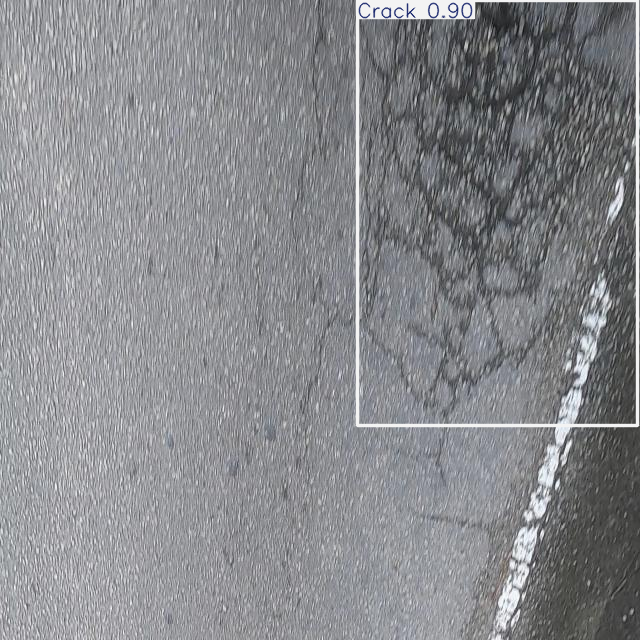

In [ ]:
from ultralytics import YOLO

# Load the best trained model weights
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Define the path to the test image
test_image_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg"

# Perform prediction on the test image
results = model.predict(test_image_path, imgsz=512, conf=0.3)

# Visualize the results
results[0].show()

Performing prediction on: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg: 512x512 2 Speedbumps, 9.9ms
Speed: 2.8ms preprocess, 9.9ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/predict_test_images/predict3
1 label saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/predict_test_images/predict3/labels


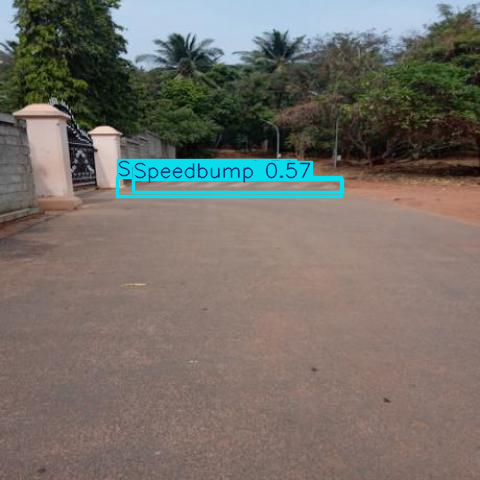


Prediction results (annotated image and labels) saved to: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/predict_test_images/predict


In [ ]:
from ultralytics import YOLO
import os

# Load the best trained model weights
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Define the path to another test image
# speebump image
new_test_image_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg"

# Define a directory to save the prediction results
save_prediction_dir = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/predict_test_images"
os.makedirs(save_prediction_dir, exist_ok=True)

print(f"Performing prediction on: {new_test_image_path}")
# Perform prediction on the test image and save the results
predict_results = model.predict(
    new_test_image_path,
    imgsz=512, # Use the same image size as during training
    conf=0.3,  # Confidence threshold
    save=True,
    save_conf=True, # Save confidence scores on bounding boxes
    save_txt=True, # Save prediction labels in TXT format
    project=save_prediction_dir # Specify the project directory to save results
)



predict_results[0].show()

print(f"\nPrediction results (annotated image and labels) saved to: {save_prediction_dir}/predict")

In [ ]:
from ultralytics import YOLO

# Load the best trained model weights
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Run full evaluation on the test set
# This will generate the metrics object and save plots to the specified project/name directory
metrics = model.val(
    data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
    split="test", # Ensure evaluation is on the test split
    imgsz=512, # Use the same image size as during training
    project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",
    name="road_anomaly_v1_full_evaluation", # unique name
    save_json=True,
    save_txt=True,
    plots=True
)

print("\n--- Full Evaluation Results on Test Set ---")
print(f"Precision (P): {metrics.box.p.mean():.3f}") # Mean precision across all classes


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 32.1±18.0 MB/s, size: 74.6 KB)
val: Scanning /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/labels.cache... 928 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 928/928 229.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 4.3s/it 4:08
                   all        928       1455      0.843      0.772      0.859      0.552
               Pothole        291        611      0.855      0.695       0.81      0.462
             Speedbump        360        415       0.88      0.894      0.938      0.626
                 Crack        276        429      0.796      0.726      0.828      0.568
Speed: 4.9ms preprocess, 217.3ms inference, 0.0ms loss, 1.0ms postprocess per image
Saving /co

Using existing 'metrics' object for plotting Confusion Matrix.


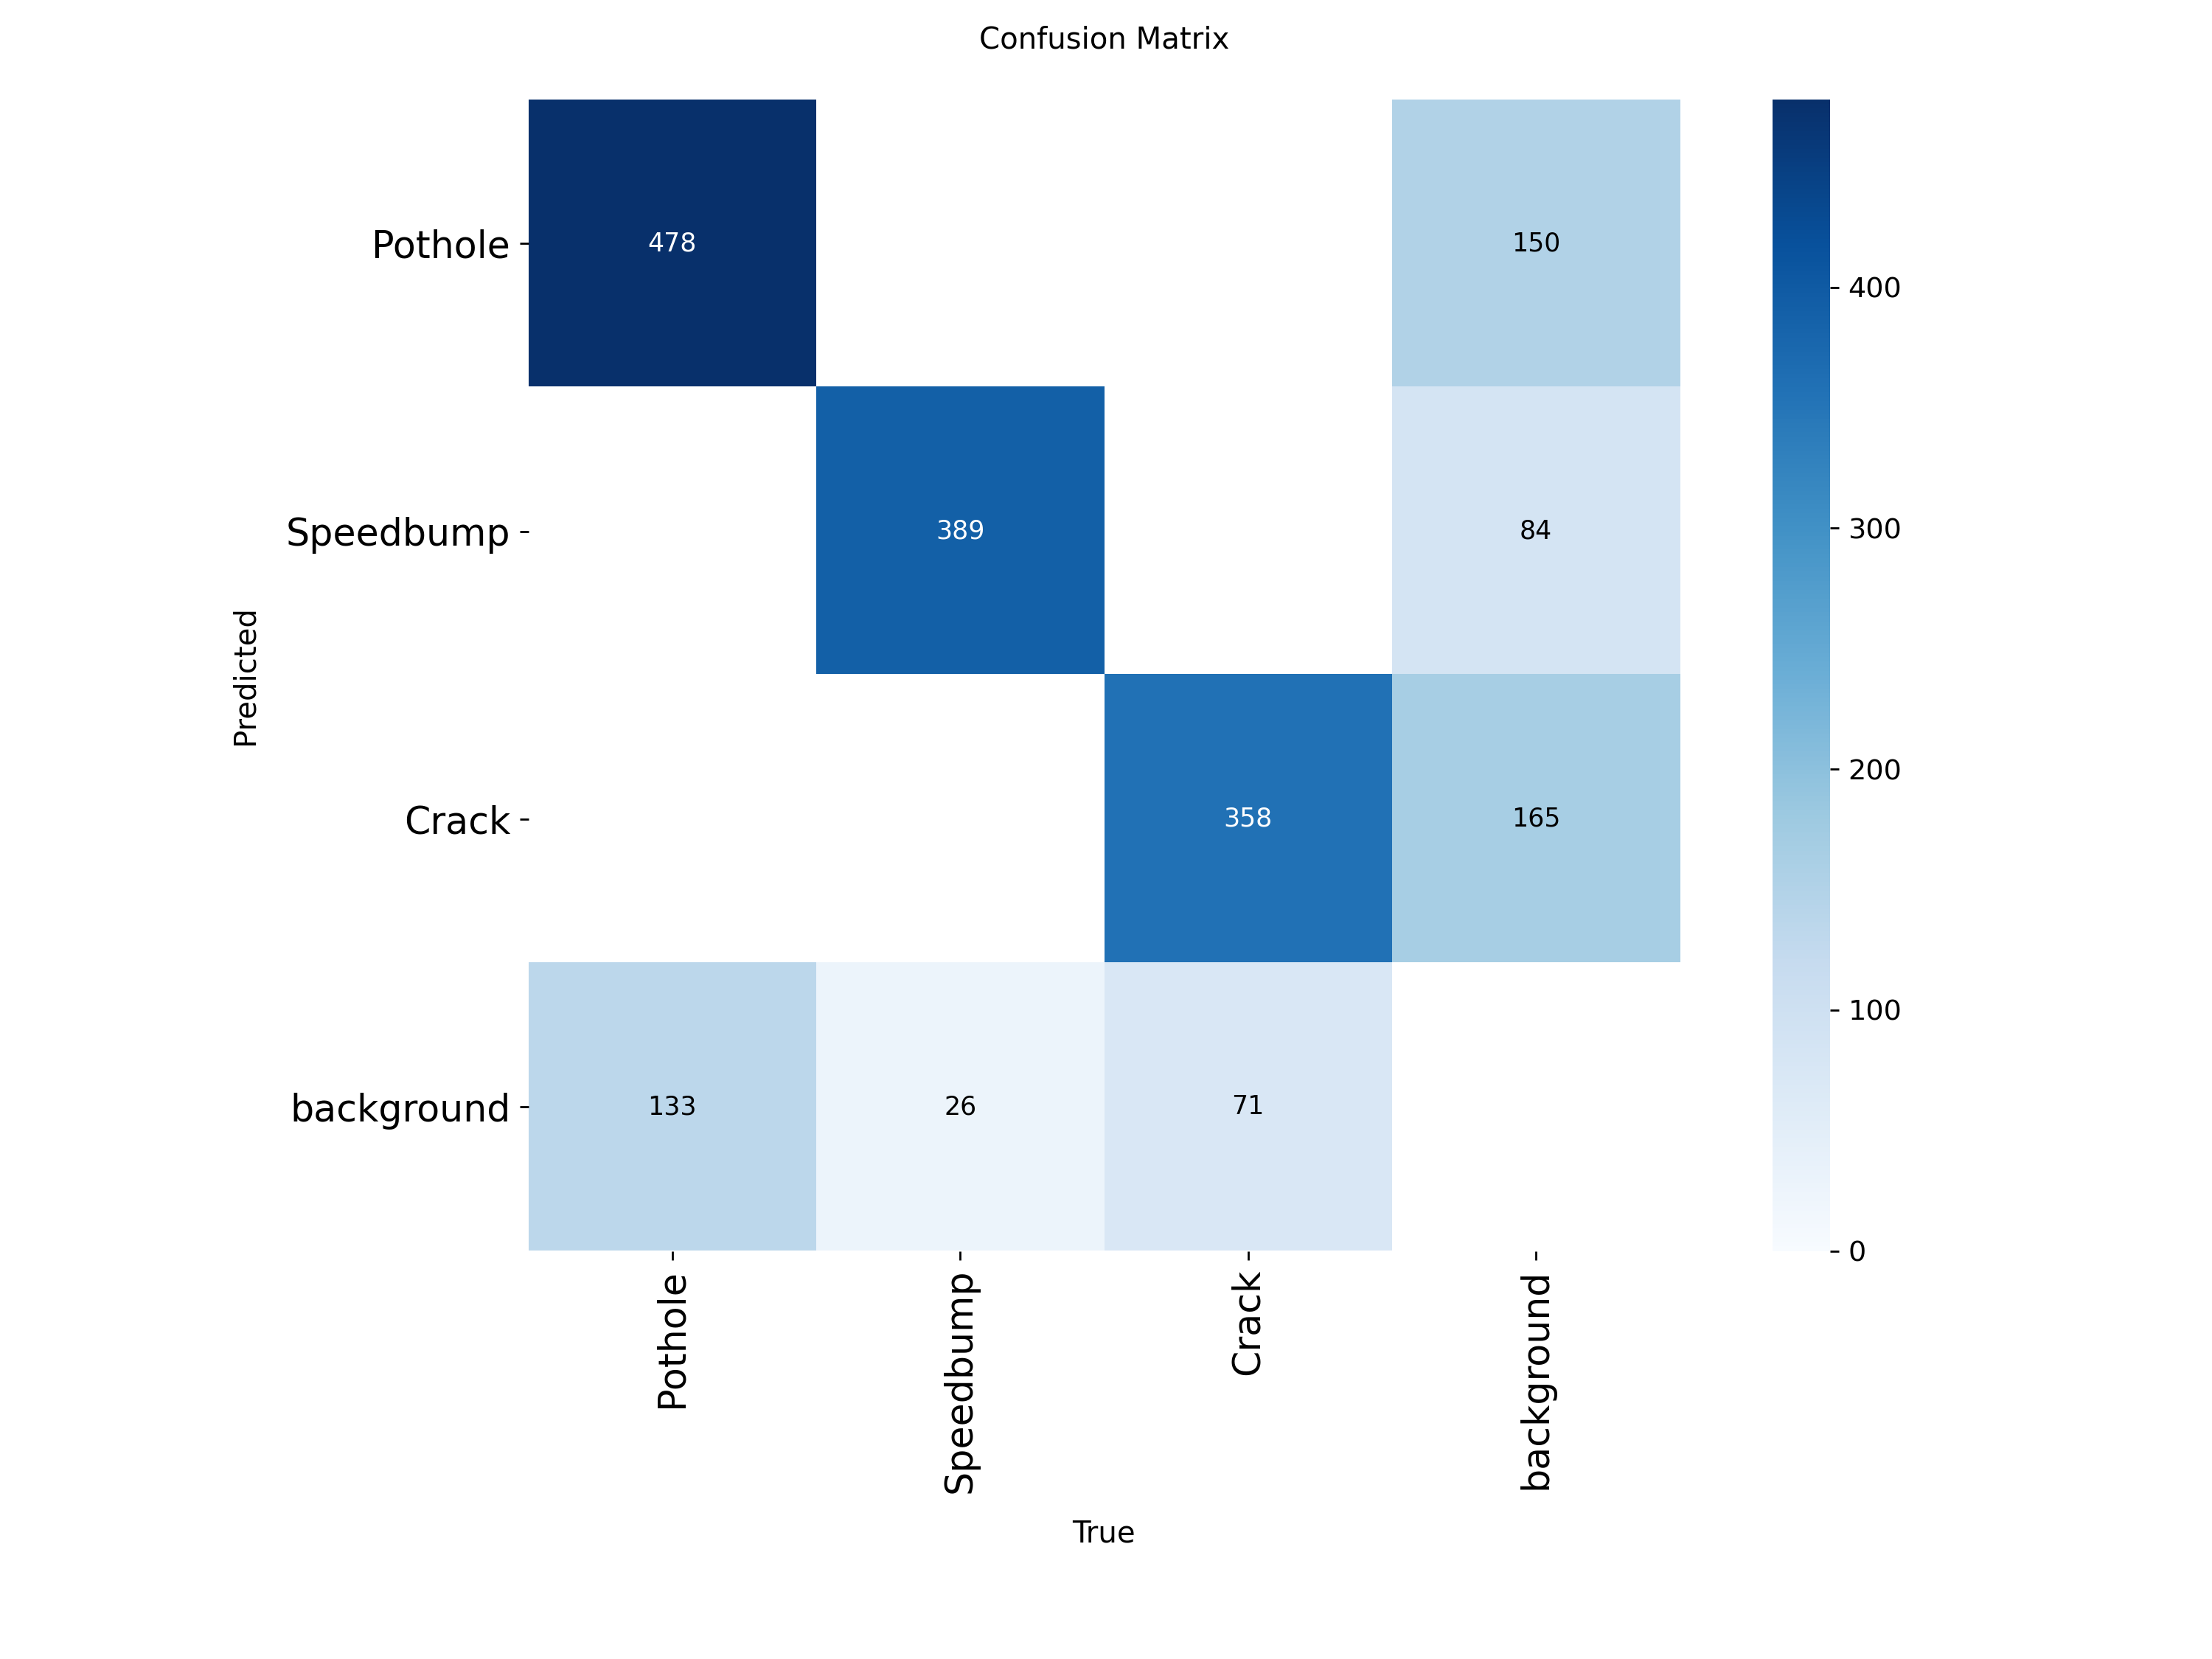

Confusion Matrix displayed from: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1_full_evaluation/confusion_matrix.png


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

# Ensure the 'metrics' object is available. If your session restarted, you may need to re-run the model.val() command.
# For demonstration, we'll re-load the model and re-run val if 'metrics' is not defined.
# In a continuous session, you can skip re-running model.val() if 'metrics' is already from the last run.

try:
    # Attempt to use the existing metrics object from the previous successful validation run
    if 'metrics' not in locals() or metrics is None:
        raise NameError("'metrics' object not found, re-running validation")
    print("Using existing 'metrics' object for plotting Confusion Matrix.")
except NameError:
    print("Re-running model.val() to get the 'metrics' object for plotting Confusion Matrix.")
    model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")
    metrics = model.val(
        data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
        split="test", # Ensure evaluation is on the test split
        imgsz=512, # Use the same image size as during training
        project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",
        name="road_anomaly_v1_full_evaluation", # A distinct name for this evaluation run
        save_json=True,
        save_txt=True,
        plots=True
    )



# Explicitly display the saved confusion matrix image
confusion_matrix_path = os.path.join(metrics.save_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    display(Image(filename=confusion_matrix_path))
    print(f"Confusion Matrix displayed from: {confusion_matrix_path}")
else:
    print(f"Error: confusion_matrix.png not found at {confusion_matrix_path}. Please ensure model.val() was run with plots=True.")

In [ ]:
!pip install ultralytics
from ultralytics import YOLO
from collections import Counter
import os

# Load the best trained model weights
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Define the path to your test images directory
test_images_dir = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images"

# Initialize a Counter to store class counts
class_counts = Counter()

print(f"Running predictions on all images in: {test_images_dir}\n")

# Setting verbose=False to avoid excessive console output for each image
results = model.predict(test_images_dir, imgsz=512, conf=0.3, verbose=False)

# Iterate through the results and count detected classes
for r in results:
    for box in r.boxes:
        class_id = int(box.cls[0]) # Get the class ID for each detected box
        class_counts[class_id] += 1


# The model.names attribute provides the mapping from integer ID to class string
class_names = model.names # This will be a dictionary like {0: 'Pothole', 1: 'Speedbump', ...} similarly

print("\n Detected Class Counts in Test Images")
if class_counts:
    for class_id, count in class_counts.items():
        class_name = class_names.get(class_id, f"Unknown Class (ID: {class_id})")
        print(f"- {class_name}: {count} detections")
else:
    print("No anomalies detected across the test images with the given confidence threshold.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Running predictions on all images in: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images


--- Detected Class Counts in Test Images ---
- Crack: 456 detections
- Pothole: 551 detections
- Speedbump: 447 detections



--- Visualizing Predictions for: 00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg: 512x512 1 Crack, 29.5ms
Speed: 7.9ms preprocess, 29.5ms inference, 13.8ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions/00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a4


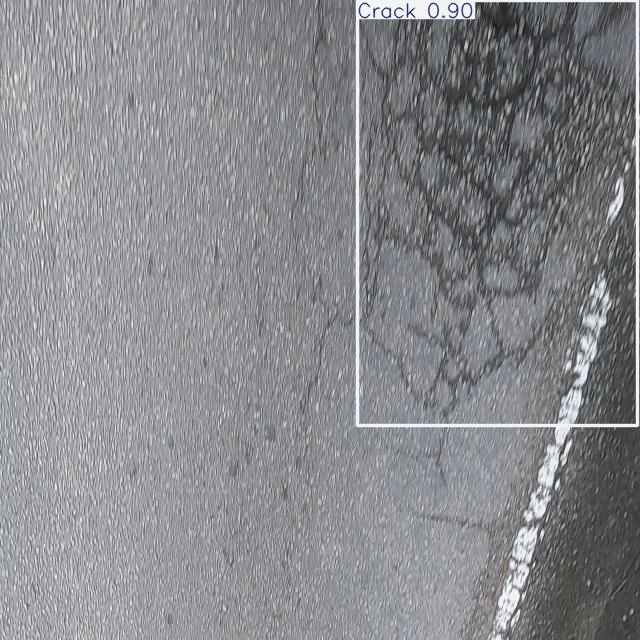

Detected anomalies:
  - Crack (Confidence: 0.90)

--- Visualizing Predictions for: 00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd.jpg ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd.jpg: 512x512 1 Crack, 54.4ms
Speed: 7.5ms preprocess, 54.4ms inference, 10.2ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions/00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd3


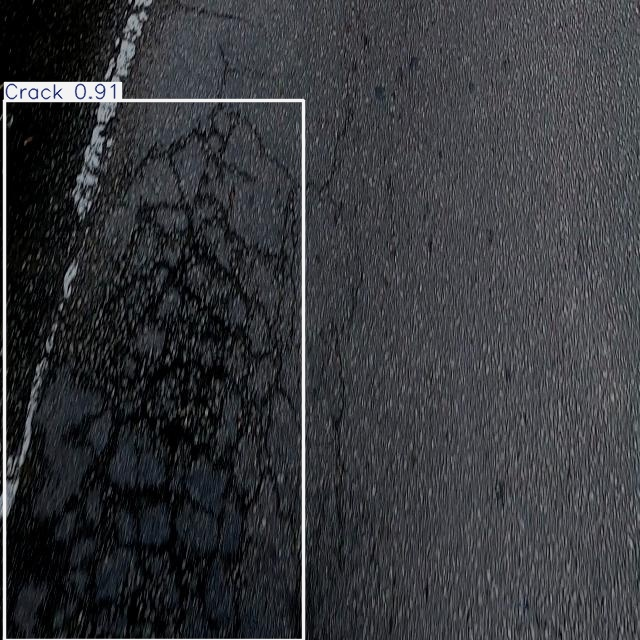

Detected anomalies:
  - Crack (Confidence: 0.91)

--- Visualizing Predictions for: 00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd8.jpg ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd8.jpg: 512x512 1 Crack, 42.8ms
Speed: 11.8ms preprocess, 42.8ms inference, 9.1ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions/00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd83


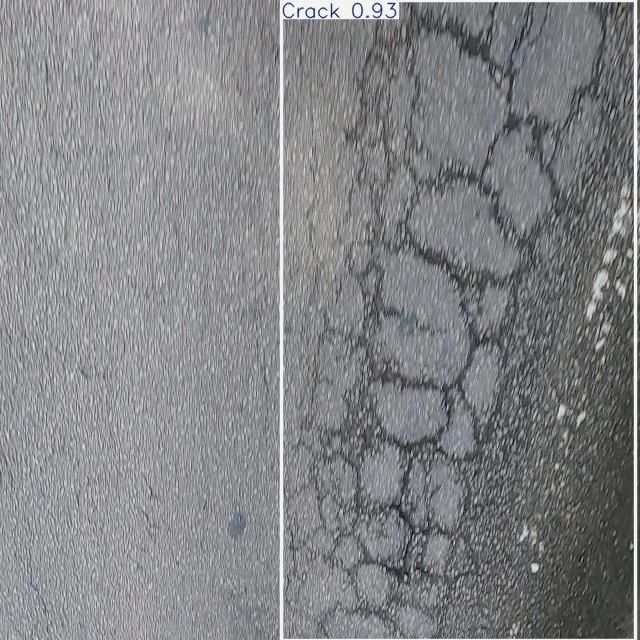

Detected anomalies:
  - Crack (Confidence: 0.93)

--- Visualizing Predictions for: 00100_jpg.rf.c4809007643425568a57af8267f8d03e.jpg ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00100_jpg.rf.c4809007643425568a57af8267f8d03e.jpg: 512x512 1 Crack, 48.0ms
Speed: 9.1ms preprocess, 48.0ms inference, 4.1ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions/00100_jpg.rf.c4809007643425568a57af8267f8d03e3


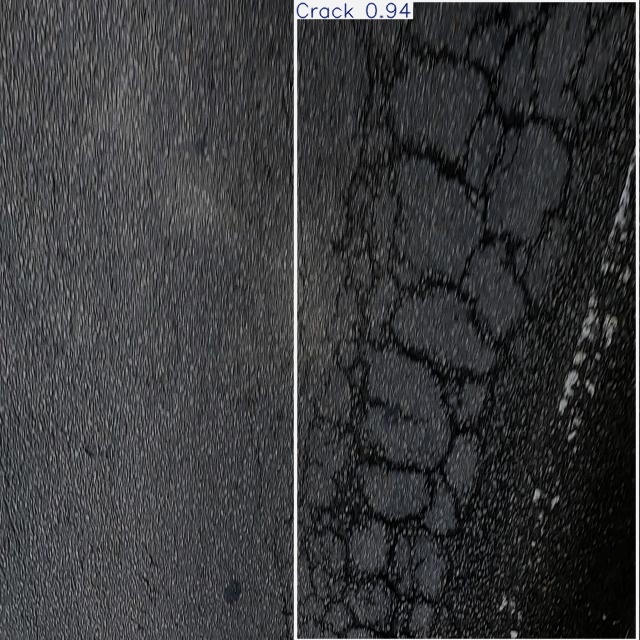

Detected anomalies:
  - Crack (Confidence: 0.94)

--- Visualizing Predictions for: 00125_jpg.rf.374e775cb072de2e827b58d41776b99c.jpg ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/00125_jpg.rf.374e775cb072de2e827b58d41776b99c.jpg: 512x512 1 Crack, 54.6ms
Speed: 11.2ms preprocess, 54.6ms inference, 11.8ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions/00125_jpg.rf.374e775cb072de2e827b58d41776b99c3


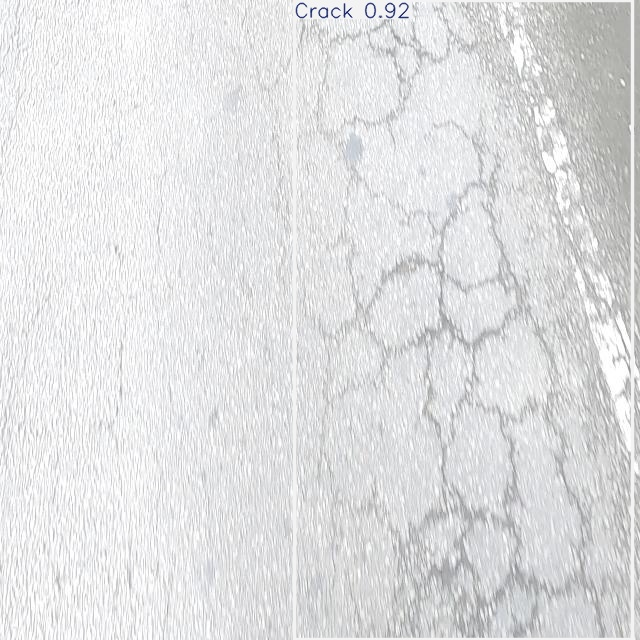

Detected anomalies:
  - Crack (Confidence: 0.92)

--- Visualizing Predictions for: 100_jpg.rf.d212f4c364a9d9980eee8b751f559a61.jpg ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/100_jpg.rf.d212f4c364a9d9980eee8b751f559a61.jpg: 512x512 1 Pothole, 31.3ms
Speed: 17.8ms preprocess, 31.3ms inference, 3.5ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions/100_jpg.rf.d212f4c364a9d9980eee8b751f559a61


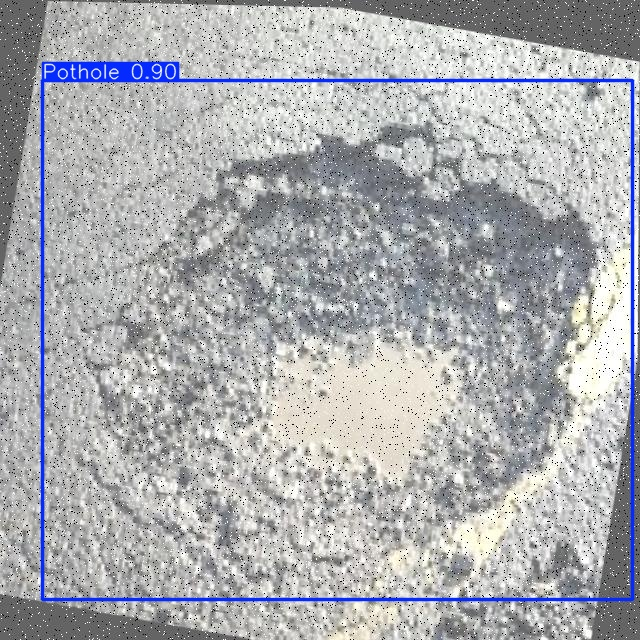

Detected anomalies:
  - Pothole (Confidence: 0.90)

--- Visualizing Predictions for: Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg ---

image 1/1 /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images/Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg: 512x512 2 Speedbumps, 44.6ms
Speed: 13.1ms preprocess, 44.6ms inference, 11.3ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions/Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784


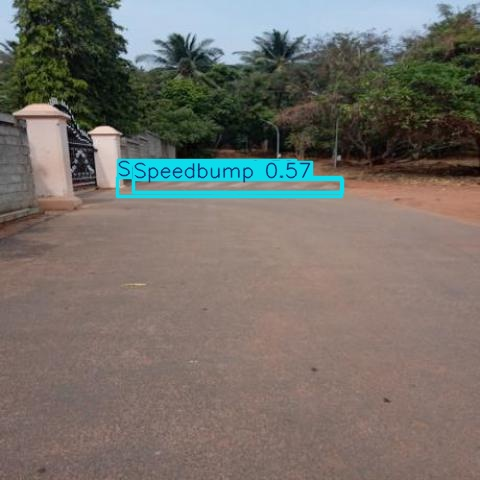

Detected anomalies:
  - Speedbump (Confidence: 0.57)
  - Speedbump (Confidence: 0.38)


In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image, display

# Load the best trained model weights
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Define the directory containing test images
test_images_dir = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images"

# --- Select sample images that are likely to contain different anomaly types ---
# Based on the previous class counts, we know all three classes are present.
# We will try to pick images that might showcase these from the provided list.

sample_images_to_display = [
    '00033_jpg.rf.c2f03baedde32081d3fbb03885d1c06a.jpg', # Example from original list
    '00039_jpg.rf.03810b4d85d83c98d58ccb985dfdcbdd.jpg', # Another example from original list
    '00096_jpg.rf.81d15bda4fac8432a37ad3afd6067fd8.jpg', # New image from list
    '00100_jpg.rf.c4809007643425568a57af8267f8d03e.jpg', # New image from list
    '00125_jpg.rf.374e775cb072de2e827b58d41776b99c.jpg',  # New image from list
    '100_jpg.rf.d212f4c364a9d9980eee8b751f559a61.jpg',
    'Image00283_jpg.rf.008f33d0714368fc1f2d39d41785b784.jpg'

]

# Define a temporary directory to save prediction results for displaying
# This helps ensure the displayed images are the ones just predicted.
save_prediction_display_dir = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/display_anomaly_predictions"
os.makedirs(save_prediction_display_dir, exist_ok=True)

for image_name in sample_images_to_display:
    image_path = os.path.join(test_images_dir, image_name)
    if os.path.exists(image_path):
        print(f"\nVisualizing Predictions for: {image_name} ")

        # Perform prediction and save the results in a unique subdirectory per image to avoid overwrites
        predict_results = model.predict(
            image_path,
            imgsz=512,  # Use the same image size as during training
            conf=0.3,   # Confidence threshold
            save=True,  # Save the predicted image with bounding boxes
            save_conf=True, # Save confidence scores on bounding boxes
            project=save_prediction_display_dir,
            name=os.path.splitext(image_name)[0] # Use image name as run name for distinct subfolders
        )

        # Get the actual save directory from the results object
        if predict_results and hasattr(predict_results[0], 'save_dir'):
            predicted_image_path = os.path.join(predict_results[0].save_dir, image_name)
            if os.path.exists(predicted_image_path):
                display(Image(filename=predicted_image_path))
            else:
                print(f"Predicted image not found at {predicted_image_path}")
        else:
             print(f"Could not determine save directory for {image_name}.")

        # Print detected anomalies
        if predict_results and len(predict_results[0].boxes) > 0:
            print("Detected anomalies:")
            for box in predict_results[0].boxes:
                class_id = int(box.cls)
                confidence = box.conf.item()
                class_name = model.names[class_id]
                print(f"  {class_name} (Confidence: {confidence:.2f})")
        else:
            print("No anomalies detected.")
    else:
        print(f"Image not found: {image_path}")


In [ ]:
%pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 99.7 MB/s eta 0:00:00


In [ ]:
%pip install opencv-python

ONNX model for a mobile app

The previous ONNX inference demonstration used a simplified post-processing. For a robust inference pipeline, we need to implement full post-processing, which typically involves:

1.  **Decoding Bounding Box Predictions**: Converting raw model outputs into meaningful bounding box coordinates, confidence scores, and class predictions.
2.  **Non-Maximum Suppression (NMS)**: Filtering overlapping bounding boxes to keep only the most confident and representative detections.
3.  **Scaling Bounding Boxes**: Rescaling the bounding box coordinates back to the original image dimensions, as the model usually processes resized inputs.

Here, we'll demonstrate a more complete post-processing pipeline. We'll reuse the `road_anomaly_yolov8n.onnx` model and a sample image.

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

model.export(
    format="onnx",
    imgsz=512,
    opset=12,
    dynamic=False
)


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 204ms
Prepared 4 packages in 1.92s
Installed 4 packages in 397ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 3.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: sta

'/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.onnx'

In [ ]:
from ultralytics import YOLO
import os

# Load the best trained PyTorch model
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

# Define the path where the ONNX model *will be saved by default*
onnx_model_path = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.onnx"

print(f"Exporting model to ONNX format. It will be saved to: {onnx_model_path}")

# Export the model to ONNX format without specifying 'filename' or 'path'
# This relies on Ultralytics' default saving behavior within the project/name directory.
exported_model_path = model.export(
    format='onnx',
    imgsz=512, # Use the same image size as during training
    opset=13,
    dynamic=False # Set to True for dynamic batch sizes
)

print(f"Model exported successfully to: {exported_model_path}")

# Verify that the file exists at the expected path
if os.path.exists(exported_model_path):
    print(f"Verification: ONNX model found at {exported_model_path}")
else:
    print(f"Error: ONNX model NOT found at {exported_model_path}")

Exporting model to ONNX format. It will be saved to: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.onnx
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 13...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.4s, saved as '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.onnx' (11.6 MB)

Export complete (1.8s)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive

This command installs the special 'ultralytics' tools we need to work with our object detection model. It's like getting the right software on your computer so it knows how to do its job.

Here, we're bringing in the main 'YOLO' tool and loading a pre-made, basic version of the YOLO model. Think of it as getting a basic, smart assistant ready to learn about new things.

This code connects our workspace to your Google Drive. It's like plugging in a USB drive so we can access files you've stored there, like our training data.

This was just a quick look inside our current workspace to see what files and folders are hanging around. It helps us know where things are.

Another quick check to see the files and folders, making sure everything is where we expect it to be, especially after some initial setup.

We checked inside the 'train' and 'val' folders to see what's in them. These folders usually hold our training and validation data, which are pictures the model will learn from and then test itself on.

This code unzipped a special 'road.zip' file from your Google Drive. This zip file contained all the images and labels our model needs to learn about potholes, speedbumps, and cracks. We put these files into a specific folder in your Drive so the model could find them.

After unzipping, we checked inside the folder on your Google Drive to make sure all the training, validation, and test data (images and labels) were there, ready for our model to use. It's like checking the groceries are all in the fridge.

We took a quick peek at the first few image files in the training folder. This was to see what kind of pictures our model would be learning from, just to get a feel for the data.

This cell was important for making sure our `data.yaml` file was correct. This file is like a roadmap for the model, telling it where all the training pictures are, what the different types of anomalies are (like Pothole, Speedbump, Crack), and how many of them there are. We checked it to make sure it wasn't empty or broken.

This was the big one! We told our YOLO model to start learning. We gave it all the training images and told it to look for Potholes, Speedbumps, and Cracks over many "epochs" (think of these as rounds of learning). It went through the pictures many times to get really good at spotting these things. The results of this learning were saved in a special folder.

This code looked at the raw numbers from our model's performance to show us a "confusion matrix." This is a table that tells us how many times the model correctly identified an anomaly, and how many times it might have mixed them up or missed them completely. We saw both the raw counts and the percentages.

This code tried to show us the Precision-Recall Curve. This is a special graph that helps us understand how good our model is at finding *all* the anomalies without making too many wrong guesses. If it couldn't show it directly, it just meant the image was saved somewhere we could look at it later.

This was another quick check to list all the files and folders in our main project area on Google Drive. It helps keep track of everything, especially the results from our model's training.

After our model finished learning, this code put it to the test on a separate set of images it had *never* seen before (the 'test' dataset). It then gave us a report card, showing important scores like Precision, Recall, and mAP, which tell us how well the model performed at finding all the anomalies. It saved all these results too!

We listed the first few image names from our test folder. This was just to help us pick specific images to visually check the model's predictions. Think of it as scanning through a photo album.

This code used our trained model to look at *one specific test image*. It drew a box around any anomaly it found and told us what it saw. This helps us visually see if the model is working correctly on individual pictures.

Similar to the last step, we tested our model on *another* specific image, this time one we hoped would show a speedbump. It drew boxes around what it detected and saved the result, showing us how it performed on another example.

This cell ran a complete evaluation of our best-trained model on the 'test' images one more time. It calculated all the performance scores (like Precision and Recall) and saved pictures of the confusion matrix and other helpful graphs. This ensures we have the most up-to-date and complete report card for our model.

This code finally showed us the "confusion matrix" picture. This colorful graph visually represents how well our model identified different types of anomalies and where it might have made mistakes. It's a great summary of the model's performance!

This code made our model scan *all* the test images and count up how many of each type of anomaly (Pothole, Speedbump, Crack) it detected across the entire test dataset. It gave us a total count for each, which is useful for knowing what's most common.

Here, we picked a few example test images and had our model predict on them. Then, we displayed these images with the detected anomalies highlighted, so we could see firsthand how well the model was finding different types of road problems in action!

This bit of code made sure we had all the right tools installed, especially 'onnxruntime', which is super important for running our converted model later on!

We also checked if 'opencv-python' was ready to go. It's like the eyes of our program for handling images, and it was already installed, so we're good!

Here's where the magic happened! We took our smart YOLO model and turned it into a 'ONNX' format. Think of it as packing up a fancy, high-tech gadget into a universal box that any device can open and understand, like a mobile app. This makes it super easy to use our anomaly detector on different platforms.

This was a quick check to make sure our model was *really* converted and saved correctly in that handy ONNX format. All good to go!

Finally, this code used our newly converted ONNX model to look at a test image. It found anomalies (like that crack!) and then showed you the picture with a neat box around what it found. This proves our model can work outside of training and find real-world problems!

### Instructions to Export Data for Power BI

First, let's make sure we have all the data ready to be exported. We have two main sets of results that would be useful:
1.  **Model Evaluation Metrics**: Precision, Recall, mAP from the `metrics` object.
2.  **Anomaly Counts**: The total number of Potholes, Speedbumps, and Cracks detected across the test set.

In [ ]:
import pandas as pd
import os

# Define the directory to save the exported CSVs
export_dir = "/content/drive/MyDrive/Lorion_Raviondran_0742950760_FinalCW/exported_data"
os.makedirs(export_dir, exist_ok=True)

# --- 1. Export Model Evaluation Metrics ---
# Ensure 'metrics' object is available from the model.val() run
# Re-running the validation cell to ensure 'metrics' is available
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")
metrics = model.val(
    data="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml",
    split="test", # Ensure evaluation is on the test split
    imgsz=512, # Use the same image size as during training
    project="/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect",
    name="road_anomaly_v1_full_evaluation", # unique name
    save_json=True,
    save_txt=True,
    plots=True
)


if 'metrics' in locals() and metrics is not None:
    metric_names = ['Pothole', 'Speedbump', 'Crack'] # Assuming these are your class names

    # Create a DataFrame for individual class metrics
    metrics_df = pd.DataFrame({
        'Class': metric_names,
        'Precision': metrics.box.p,
        'Recall': metrics.box.r,
        'mAP50': metrics.box.map50_class,
        'mAP50-95': metrics.box.map_class
    })

    # Add overall metrics if desired
    overall_metrics = pd.DataFrame({
        'Class': ['Overall'],
        'Precision': [metrics.box.p.mean()],
        'Recall': [metrics.box.r.mean()],
        'mAP50': [metrics.box.map50],
        'mAP50-95': [metrics.box.map]
    })
    metrics_df = pd.concat([metrics_df, overall_metrics], ignore_index=True)

    metrics_filepath = os.path.join(export_dir, 'model_evaluation_metrics.csv')
    metrics_df.to_csv(metrics_filepath, index=False)
    print(f"Model evaluation metrics exported to: {metrics_filepath}")
else:
    print("Metrics object not found. Please run the model.val() cell first.")

# --- 2. Export Anomaly Counts ---
# Re-running the prediction cell to ensure 'class_counts' is available
from collections import Counter

# Define the path to your test images directory
test_images_dir = "/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/test/images"

# Initialize a Counter to store class counts
class_counts = Counter()

print(f"Running predictions on all images in: {test_images_dir}\n")

# Setting verbose=False to avoid excessive console output for each image
results = model.predict(test_images_dir, imgsz=512, conf=0.3, verbose=False)

# Iterate through the results and count detected classes
for r in results:
    for box in r.boxes:
        class_id = int(box.cls[0]) # Get the class ID for each detected box
        class_counts[class_id] += 1


if 'class_counts' in locals() and class_counts and 'model' in locals() and model.names:
    counts_data = []
    for class_id, count in class_counts.items():
        class_name = model.names.get(class_id, f"Unknown (ID:{class_id})")
        counts_data.append({'Class': class_name, 'Count': count})

    counts_df = pd.DataFrame(counts_data)
    counts_filepath = os.path.join(export_dir, 'anomaly_counts.csv')
    counts_df.to_csv(counts_filepath, index=False)
    print(f"Anomaly counts exported to: {counts_filepath}")
else:
    print("Anomaly counts or class names not found. Please run the anomaly counting cell first.")

print(f"\nAll exported data is saved in your Google Drive at: {export_dir}")


Metrics object not found. Please run the model.val() cell first.
Anomaly counts or class names not found. Please run the anomaly counting cell first.

All exported data is saved in your Google Drive at: /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/exported_data


### Exporting Model for Mobile Applications

Now, let's export the trained YOLOv8 model (`best.pt`) to various formats optimized for mobile and edge devices. This step is crucial for deploying your anomaly detection model in applications for Android (using TFLite) and iOS (using ONNX or CoreML).

In [ ]:
from ultralytics import YOLO

# Load the best trained PyTorch model
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

print("Exporting model to TFLite (int8 quantized) for Android...")
# For Android (TFLite — smallest & fastest on-device)
# `int8=True` enables 8-bit integer quantization for maximum size reduction and speed, suitable for mobile CPUs/NPUs.
# `imgsz` is set to 512, consistent with the training image size.
model.export(format="tflite", int8=True, imgsz=512)

print("TFLite export complete. The quantized model will be saved as `best_int8.tflite` in the weights directory.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Exporting model to TFLite (int8 quantized) for Android...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)
requir

In [ ]:
from ultralytics import YOLO

# Load the best trained PyTorch model
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

print("Exporting model to optimized ONNX (float16) for iOS / ONNX Runtime Mobile...")
# For iOS / ONNX Runtime Mobile (better than your current best.onnx for mobile performance)
# `simplify=True` applies graph optimizations.
# `half=True` converts weights to float16, reducing size and improving performance on GPUs with float16 support.
# `opset=17` ensures compatibility with newer ONNX Runtime versions and better mobile operator support.
# `imgsz` is set to 512, consistent with the training image size.
model.export(format="onnx", simplify=True, half=True, imgsz=512, opset=17)

print("ONNX (float16) export complete. The optimized model will be saved as `best.onnx` in the weights directory, overwriting the previous one.")

Exporting model to optimized ONNX (float16) for iOS / ONNX Runtime Mobile...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: converting to FP16...
ONNX: export success ✅ 1.6s, saved as '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.onnx' (5.9 MB)

Export complete (2.0s)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/roa

In [ ]:
from ultralytics import YOLO

# Load the best trained PyTorch model
model = YOLO("/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt")

print("Exporting model to CoreML for native iOS integration...")
# Optional: CoreML for native iOS integration
# `nms=True` includes Non-Maximum Suppression directly in the CoreML model, simplifying post-processing in the app.
# `imgsz` is set to 512, consistent with the training image size.
model.export(format="coreml", nms=True, imgsz=512)

print("CoreML export complete. The model will be saved as `best.mlpackage` in the weights directory.")

Exporting model to CoreML for native iOS integration...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 7, 5376) (5.9 MB)
requirements: Ultralytics requirement ['coremltools>=9.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 165ms
Prepared 3 packages in 225ms
Installed 3 packages in 27ms
 + cattrs==26.1.0
 + coremltools==9.0
 + pyaml==26.2.1

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


CoreML: starting export with coremltools 9.0...


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 110.39 passes/s]


CoreML Pipeline: starting pipeline with coremltools 9.0...
CoreML Pipeline: pipeline success
CoreML: export success ✅ 13.4s, saved as '/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.mlpackage' (5.9 MB)

Export complete (13.9s)
Results saved to /content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.mlpackage imgsz=512 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/runs/detect/road_anomaly_v1/weights/best.mlpackage imgsz=512 data=/content/drive/MyDrive/Lorion_Ravindradasan_0742950760_FinalCW/data.yaml  
Visualize:       https://netron.app
CoreML export complete. The model will be saved as `best.mlpackage` in the weights directory.
